# T48 — Cooling rates on multi-layer paleo-Earth maps: an Earth-system view of exhumation

**Cluster F: paleo-geography and paleo-topography.**

*Based on:* Boone et al. (2025), *Communications Earth & Environment* 6, 1015. *Deciphering mantle, tectonic and climatic drivers of exhumation* — specifically the multi-layer paleo-Earth overlays produced by the ThermoPlates `03_Thermochron_GPlates.sh` script.

## What this notebook does

T47 introduced the core paleo-reconstruction of Central Asian thermochronology cooling rates. This notebook builds on that base layer by **dropping the cooling-rate samples onto four complementary Earth-system rasters at the same snapshot age**:

1. **Seafloor age** (Zahirovic et al. 2022 age grid) — the oceanic-plate context.
2. **Dynamic topography** (Young et al. 2022 `gld428`) — the mantle-flow surface signal.
3. **Paleotopography** (geochemistry-corrected Scotese & Wright 2018) — the inherited continental relief.
4. **Paleoprecipitation** — wired as an optional fourth layer; a Valdes-Scotese precipitation grid loader is sketched in *Extend this*.

The notebook also writes out a `thermochron_master_{AGE}.parquet` table — per-sample lon, lat, cooling rate, DT, ΔDT, paleotopography — that **T50** (cooling-rate correlations + time-series) consumes directly.

**Audience**: postgrad → researcher.
**Difficulty**: ★★☆.
**Runtime**: ~3 min for a single snapshot, ~10 min for the 5-snapshot grid at the end.

## Learning objectives

- Stack multiple time-varying rasters (`xarray.DataArray`) and reconstructed point samples (`gplately.Points`) on a single paleo-Earth map.
- Use `xarray.DataArray.interp()` to sample raster values at scattered reconstructed sample positions — the Python equivalent of GMT's `grdtrack`.
- Build a per-snapshot tabular substrate (parquet) that downstream correlation/scatter notebooks (T50) can consume without re-reconstructing every sample.
- Maintain consistent map styling across multiple raster layers — useful when the same sample distribution is compared against several environmental forcings.

## Prerequisites

- T47 (Central Asia thermochronology on paleo-Earth) — same data substrate; this notebook is a logical follow-up.
- Familiarity with the `gplately.Points` reconstruction pattern and pyGMT raster compositing.
- Network access on first run only (plate model + age grid fetched via `plate_model_manager`).

## Data availability

Bundled inputs:
- `data/thermochronology_central_asia/central_asia_thermal_histories.csv` — same 5-Myr cadence subset used by T47.
- `data/young2022_dyntopo/gld428_PlateFrameGrid{AGE}.nc` — Young 2022 dynamic topography at 20-Myr cadence (0, 20, 100, 120, 200, 220, 300, 320, 400 Ma).
- `data/paleotopo_scotese/corrected_SW/{AGE}Ma_corrected_SW.nc` — geochemistry-corrected Scotese & Wright 2018 paleo-DEM at 50-Myr cadence (50, 100, 200, 300, 400, 500 Ma).

External (fetched on first run via `plate_model_manager`):
- **Zahirovic et al. 2022** rotation file, topologies, coastlines, COBs, **and age grid**.

## Source
- Upstream shell-script workflow: https://github.com/samuelcboone/ThermoPlates (script `03_Thermochron_GPlates.sh`).
- Boone et al. (2025) DOI: https://doi.org/10.1038/s43247-025-03005-6.

**Dynamic topography (Braz et al. 2021, gmcm9):** the bundled grids under `data/gmcm9/` (mantle and plate frame, 31 NetCDFs each, 0–150 Ma, ~5-Myr cadence) come from the EarthByte WebDAV server (https://www.earthbyte.org/webdav/ftp/Dynamic_Topography/gmcm9/) and are described in:

> Braz, C., Zahirovic, S., Salles, T., Flament, N., Harrington, L. and Müller, R.D., 2021. *Modelling the role of dynamic topography and eustasy in the evolution of the Great Artesian Basin.* Basin Research, 33(6), pp.3378–3405.

This is the same DT field Boone et al. (2025) used for the cooling-rate × DT overlay and correlation analyses. T48 + T50 use the **plate-frame** variant because ΔDT/Δt should be computed in the frame the upper plate sits in (T23 follows the same convention). For map overlays the resulting Δ field is rotated back to the mantle/paleomag frame via `gplately.Raster.reconstruct` so the dots and the rotated grid live in the same reference frame.

## Environment + imports

In [1]:
from pathlib import Path
import os, sys
# Run from repo root or from Notebooks/ — both resolve to the repo root.
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr

import gplately
import pygmt
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python    {sys.version.split()[0]}")
for _m in (np, pd, xr, gplately, pygmt):
    print(f"  {_m.__name__:9s} {getattr(_m, '__version__', 'n/a')}")

Environment
  python    3.12.5
  numpy     2.3.2
  pandas    2.2.3
  xarray    2026.4.0
  gplately  2.0.0.post19+git.2cce7bb3
  pygmt     v0.18.0


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model + frame.
# Boone et al. (2025) uses Zahirovic 2022 with its native mantle frame for
# the kinematic-context overlays. T48 is NOT a paleoclimate-vs-paleomag
# comparison — both DT and seafloor age are mantle-frame quantities — so
# the mantle anchor is appropriate here.
MODEL_NAME            = "Zahirovic2022"
ANCHOR_PLATE_ID       = 0      # mantle frame

# Snapshot age (Ma). 100 Ma is the default because all bundled rasters
# (Young 2022 DT, corrected Scotese-Wright paleo-DEM) have a 100 Ma slice.
RECONSTRUCTION_TIME   = 100.0

# Inputs (bundled with the suite).
HISTORIES_CSV         = Path("data/thermochronology_central_asia/central_asia_thermal_histories.csv")
REGIONS_CSV           = Path("data/thermochronology_central_asia/central_asia_regions.csv")
# Dynamic topography — Braz et al. (2021) gmcm9 PLATE-frame grids,
# bundled at data/gmcm9/PlateFrame/. Plate-frame coords are attached to
# the plate (they don\'t move with time), so we sample at each
# thermochronology sample\'s PRESENT-DAY lon/lat. For the Layer B map
# overlay (§6) we compute ΔDT/Δt in plate frame, then rotate to mantle
# frame via T23\'s rotate_plate_frame_to_paleomag pattern.
#   https://www.earthbyte.org/webdav/ftp/Dynamic_Topography/gmcm9/
# 31 NCs at ~5-Myr cadence, 0-150 Ma. Same DT field Boone et al. (2025)
# used.
DT_GRID_DIR           = Path("data/gmcm9/PlateFrame")
DT_GRID_PATTERN       = "{age:.2f}.nc"
DT_STEP_MYR           = 5
PALEODEM_DIR          = Path("data/paleotopo_scotese/corrected_SW")

# Map region — Central Asia (matches Boone et al. 2025 Fig. 1 extent).
REGION_CENTRAL_ASIA   = [55, 130, 35, 60]   # [W, E, S, N]

# Cooling-rate visual scale (Boone et al. 2025 conventions: 0-3 °C/Myr).
COOLING_CPT_RANGE     = (0.0, 3.0)

# Where to write the per-snapshot tabular substrate for T50.
MASTER_PARQUET_DIR    = Path("data/thermochronology_central_asia/thermochron_master")
MASTER_PARQUET_DIR.mkdir(parents=True, exist_ok=True)
# ============================================================================

## 1. Load the plate model, age grid, and thermochronology compilation

In [3]:
# Plate model + reconstruction
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
engine = gplately.PygmtPlotEngine()
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECONSTRUCTION_TIME),
    plot_engine=gplately.PygmtPlotEngine(),
)

# Age grid (fetched on first run)
agegrid_da = xr.open_dataarray(
    model.get_raster("AgeGrids", time=float(RECONSTRUCTION_TIME))
)
print(f"  Z22 age grid at {RECONSTRUCTION_TIME:.0f} Ma: shape={agegrid_da.shape}, "
      f"valid range {float(agegrid_da.min()):.1f} – {float(agegrid_da.max()):.1f} Ma")

  Z22 age grid at 100 Ma: shape=(1801, 3601), valid range 0.0 – 238.7 Ma


In [4]:
# Load Central Asia thermal histories (long format: one row per sample per Myr).
hist = pd.read_csv(HISTORIES_CSV, comment="#")
regions = pd.read_csv(REGIONS_CSV)
print(f"  histories: {len(hist):,} rows, {hist['sample_name'].nunique()} unique samples")
print(f"  regions:   {len(regions)} rows")
hist.head(3)

  histories: 23,119 rows, 377 unique samples
  regions:   7 rows


,lat,lon,sample_name,TOAGE,FROMAGE,OnlyCooling,TempDiff,Region,Sub-Region
0,41.049722,75.655944,AI-69,300,300.999,NaN,NaN,1.0,1.0
1,41.049722,75.655944,AI-69,295,295.999,NaN,NaN,1.0,1.0
2,41.049722,75.655944,AI-69,290,290.999,NaN,NaN,1.0,1.0


## 2. Per-sample cooling rate at the snapshot age

For each sample we read the cooling rate (°C/Myr) **active at** `RECONSTRUCTION_TIME`
from Boone et al. (2025)'s pre-computed `TempDiff` column — the per-sample,
per-window cooling rate that the upstream `01_Thermochronology_Assessment.sh` script
uses for every downstream analysis. We do **not** recompute it from
`OnlyCooling` and the age window: `OnlyCooling` is the cumulative
cooling-only envelope, not the instantaneous rate, and dividing it by the
interval duration yields values roughly two orders of magnitude too large.

Boone et al. (2025) classify cooling rates into three bands — *fast* (>0.5 °C/Myr),
*very fast* (>1.0 °C/Myr) and *extra fast* (>1.5 °C/Myr) — so the natural
colour-scale range for visualisation is 0–3 °C/Myr (matching their
`thermochron_v1.cpt`). The figures below use this fixed range to keep the
colour mapping comparable across snapshot ages and across figures.

In [5]:
def per_sample_cooling_at(age_ma: float, hist_df: pd.DataFrame) -> pd.DataFrame:
    """Return one row per sample with the cooling rate (°C/Myr) at `age_ma`.

    Uses Boone et al. (2025)'s pre-computed *TempDiff* column directly —
    this is the per-sample, per-window cooling rate (°C/Myr) that the
    upstream ThermoPlates workflow uses for every downstream analysis
    (column 7 of the source CSV; cf. T47's note). Recomputing from
    OnlyCooling/duration gives values ~100× too large because OnlyCooling
    is the cumulative cooling-only envelope, NOT the instantaneous rate.
    """
    snap = hist_df.loc[hist_df["TOAGE"] == int(age_ma)].copy()
    snap["cooling_rate"] = pd.to_numeric(snap["TempDiff"], errors="coerce")
    snap = snap.dropna(subset=["cooling_rate", "lat", "lon"]).copy()
    snap["cooling_rate"] = snap["cooling_rate"].clip(lower=0)
    # Collapse to one row per sample.
    return (snap.groupby("sample_name", as_index=False)
                .agg(lat=("lat", "first"),
                     lon=("lon", "first"),
                     cooling_rate=("cooling_rate", "mean")))

samples_now = per_sample_cooling_at(RECONSTRUCTION_TIME, hist)
print(f"  {len(samples_now)} samples bracket {RECONSTRUCTION_TIME:.0f} Ma — "
      f"cooling-rate range {samples_now['cooling_rate'].min():.2f} – "
      f"{samples_now['cooling_rate'].max():.2f} °C/Myr")

  286 samples bracket 100 Ma — cooling-rate range 0.00 – 5.44 °C/Myr


## 3. Reconstruct sample positions to the snapshot age

`gplately.Points.reconstruct` returns reconstructed coordinates as `(rlons, rlats)`
— **longitudes first**, an easy ordering trap (see CLAUDE.md GPlately gotchas).

In [6]:
gpts = gplately.Points(recon,
                       samples_now["lon"].to_numpy(float),
                       samples_now["lat"].to_numpy(float),
                       anchor_plate_id=ANCHOR_PLATE_ID)
rlons, rlats = gpts.reconstruct(RECONSTRUCTION_TIME,
                                 return_array=True,
                                 anchor_plate_id=ANCHOR_PLATE_ID)
samples_now["rlon"] = rlons
samples_now["rlat"] = rlats
samples_now = samples_now.dropna(subset=["rlon", "rlat"]).copy()
print(f"  reconstructed {len(samples_now)} samples to {RECONSTRUCTION_TIME:.0f} Ma")

  reconstructed 286 samples to 100 Ma


## 4. Sample the rasters at the reconstructed positions (`grdtrack` equivalent)

Three rasters → one DataFrame: cooling rate, DT, paleotopography per sample.
The result is the Python equivalent of Boone's `thermochron_master_{age}.xyz`
and is written to parquet for T50 to consume.

In [7]:
def sample_raster_at_points(da: xr.DataArray, lons, lats) -> np.ndarray:
    """Bilinear sample of a regular lon/lat DataArray at scattered points."""
    if "lon" in da.dims and "lat" in da.dims:
        return da.interp(lon=xr.DataArray(lons, dims="i"),
                          lat=xr.DataArray(lats, dims="i")).values
    if "x" in da.dims and "y" in da.dims:
        return da.interp(x=xr.DataArray(lons, dims="i"),
                          y=xr.DataArray(lats, dims="i")).values
    raise ValueError(f"unknown dim names: {da.dims}")

# Dynamic topography + ΔDT/Δt from Braz et al. (2021) gmcm9.
# Coverage is 0-150 Ma at ~5-Myr cadence with a few non-uniform steps
# (e.g. 129→135 instead of 130→135), so we pick the nearest available
# age rather than assuming uniform DT_STEP_MYR spacing.
# Dynamic topography + ΔDT/Δt from Braz et al. (2021) gmcm9, plate frame.
# For point sampling: plate-frame coords are attached to the plate and
# don\'t move with time, so we sample the grid at each sample\'s
# PRESENT-DAY (lon, lat) — NOT the reconstructed paleo-position. For
# the Layer B map overlay (§6) we rotate the plate-frame Δ field back
# to mantle frame via T23\'s rotate_plate_frame_to_paleomag pattern.
import re as _re
def _parse_pf_age(p):
    """Return float age in Ma for a gmcm9 PlateFrame NC filename like
    \"100.00.nc\", or None for anything else (Masked_ variants, weird files)."""
    if p.name.startswith("Masked_"):
        return None
    m = _re.search(r"^([0-9]+\.[0-9]+)\.nc$", p.name)
    return float(m.group(1)) if m else None

# Diagnostic: show the resolved DT_GRID_DIR + raw file count
print(f"  DT_GRID_DIR  : {DT_GRID_DIR.resolve()}")
_all_nc = sorted(DT_GRID_DIR.glob("*.nc"))
print(f"  .nc files in dir: {len(_all_nc)}")
if _all_nc:
    print(f"  sample names    : {[p.name for p in _all_nc[:3]]} ...")

_avail_dt_ages = sorted(
    a for a in (_parse_pf_age(p) for p in _all_nc)
    if a is not None
)
if not _avail_dt_ages:
    raise FileNotFoundError(
        f"No gmcm9 plate-frame NetCDFs matched at {DT_GRID_DIR.resolve()}. "
        f"Expected filenames like \"100.00.nc\". "
        f"Check that DT_GRID_DIR in the config cell points at "
        f"data/gmcm9/PlateFrame/ (with the suite\'s cwd at the repo root) "
        f"AND that the bundled NetCDFs are present. "
        f"Found {len(_all_nc)} .nc file(s); after filtering "
        f"(skip Masked_, require XX.XX.nc pattern), 0 remain."
    )
print(f"  gmcm9 PF cadence ({len(_avail_dt_ages)} grids): "
      f"{_avail_dt_ages[0]:.0f}..{_avail_dt_ages[-1]:.0f} Ma")

def _nearest_dt_age(target):
    return min(_avail_dt_ages, key=lambda a: abs(a - target))

dt_age      = _nearest_dt_age(RECONSTRUCTION_TIME)
dt_path     = DT_GRID_DIR / DT_GRID_PATTERN.format(age=dt_age)
dt_da_plate = xr.open_dataset(dt_path)["z"]
samples_now["dyn_topo_m"] = sample_raster_at_points(
    dt_da_plate, samples_now["lon"].values, samples_now["lat"].values)

idx          = _avail_dt_ages.index(dt_age)
later_age    = _avail_dt_ages[max(0, idx - 1)]
earlier_age  = _avail_dt_ages[min(len(_avail_dt_ages) - 1, idx + 1)]
if earlier_age != later_age:
    later_at   = sample_raster_at_points(
        xr.open_dataset(DT_GRID_DIR / DT_GRID_PATTERN.format(age=later_age))["z"],
        samples_now["lon"], samples_now["lat"])
    earlier_at = sample_raster_at_points(
        xr.open_dataset(DT_GRID_DIR / DT_GRID_PATTERN.format(age=earlier_age))["z"],
        samples_now["lon"], samples_now["lat"])
    samples_now["delta_dt_m_per_Myr"] = (later_at - earlier_at) / (earlier_age - later_age)
else:
    samples_now["delta_dt_m_per_Myr"] = np.nan
print(f"  used dt={dt_age:.0f} Ma for absolute DT; bracket "
      f"{later_age:.0f}-{earlier_age:.0f} Ma for ΔDT/Δt")

# Paleotopography (nearest 50-Myr step of corrected Scotese-Wright)
paleotopo_steps = sorted(int(p.stem.split("Ma")[0]) for p in PALEODEM_DIR.glob("*Ma_corrected_SW.nc"))
pt_age = min(paleotopo_steps, key=lambda a: abs(a - RECONSTRUCTION_TIME))
pt_path = PALEODEM_DIR / f"{pt_age}Ma_corrected_SW.nc"
# The corrected Scotese-Wright files carry six variables
# (M_orig, M_corrected, delta, province, continent_mask, n_eff); we want
# M_corrected — the geochemistry-corrected paleo-elevation in metres.
pt_ds = xr.open_dataset(pt_path)
pt_da = pt_ds["M_corrected"] if "M_corrected" in pt_ds.data_vars else pt_ds["z"]
samples_now["paleotopo_m"] = sample_raster_at_points(
    pt_da, samples_now["rlon"].values, samples_now["rlat"].values)

print(f"  DT raster used:   {dt_path.name}  ({dt_age} Ma step)")
print(f"  Paleotopo grid:   {pt_path.name}  ({pt_age} Ma step)")
samples_now.describe().T[["min", "50%", "max"]].round(2)

  DT_GRID_DIR  : /Users/dietmar/Documents/GPlates/GPlately-pyGMT_tutorials/data/gmcm9/PlateFrame
  .nc files in dir: 62
  sample names    : ['0.00.nc', '104.00.nc', '109.00.nc'] ...
  gmcm9 PF cadence (31 grids): 0..150 Ma
  used dt=99 Ma for absolute DT; bracket 94-104 Ma for ΔDT/Δt
  DT raster used:   99.00.nc  (99.0 Ma step)
  Paleotopo grid:   100Ma_corrected_SW.nc  (100 Ma step)


,min,50%,max
lat,39.25,42.95,54.40
lon,63.26,81.01,101.42
cooling_rate,0.00,0.38,5.44
rlon,57.63,73.19,95.63
rlat,36.37,44.29,55.96
dyn_topo_m,-272.11,-238.47,-221.81
delta_dt_m_per_Myr,-3.31,-0.97,0.70
paleotopo_m,-37.44,1441.70,3126.98


In [8]:
# Write the per-snapshot master table — T50 reads these in.
master_path = MASTER_PARQUET_DIR / f"thermochron_master_{int(RECONSTRUCTION_TIME):03d}Ma.parquet"
samples_now.to_parquet(master_path)
print(f"  ✓ wrote {master_path}  ({len(samples_now)} samples, {samples_now.shape[1]} cols)")

  ✓ wrote data/thermochronology_central_asia/thermochron_master/thermochron_master_100Ma.parquet  (286 samples, 9 cols)


## 5. Layer A — cooling rates × seafloor age (global orthographic)

Following Boone's `cooling_seafloorage_global_${age}.ps` — orthographic projection
centred over Central Asia, with the Z22 age grid as the ocean basemap, terranes
and plate boundaries on top, then the cooling-rate dots above them.

Following Boone et al. (2025)'s `cooling_seafloorage_global_${age}.ps`, this
panel layers the Zahirovic et al. (2022) age grid under the reconstructed
cooling-rate dots. The juxtaposition makes one specific link visible: was each
Central Asian sample close to active oceanic subduction at the time it cooled?
Boone et al. (2025) use this view to argue that the diachronous Mesozoic-to-
recent exhumation of Central Asia was tightly coupled to Tethyan subduction
dynamics — fast cooling pulses tend to track the migration of the southern
Eurasian subduction margin through time.

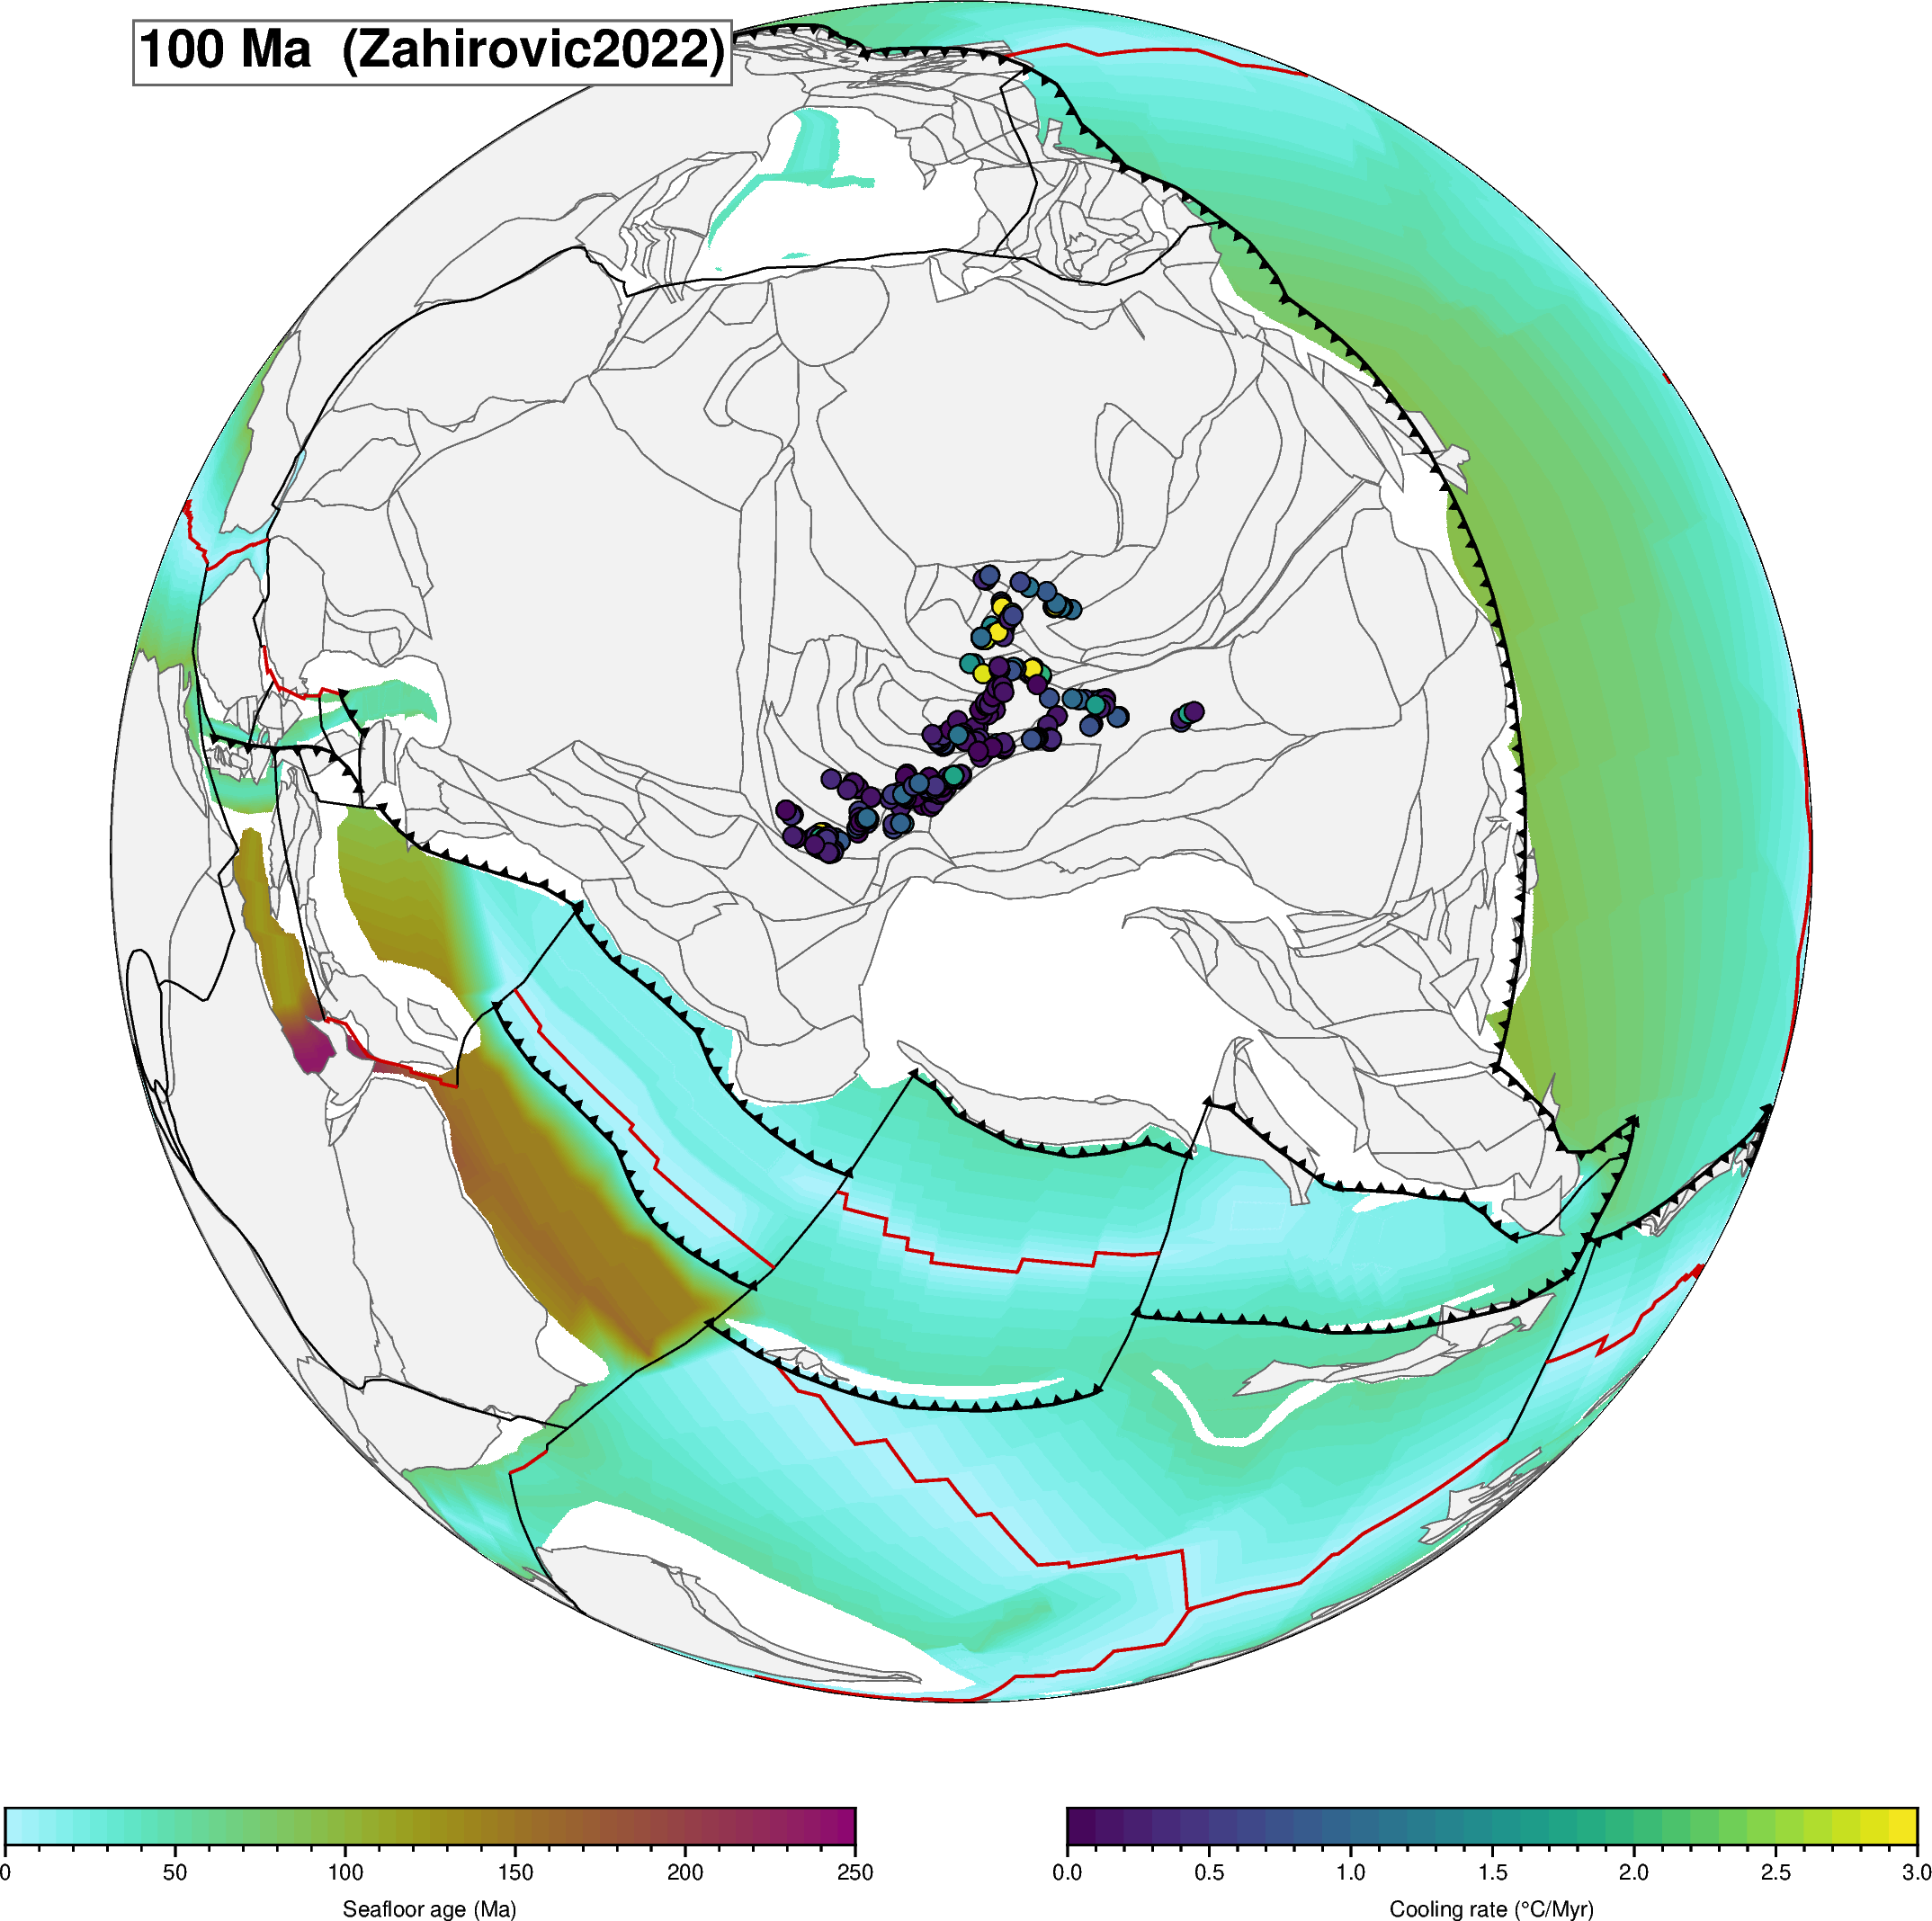

In [9]:
GLOBAL_PROJ = "G73/37/16c"   # orthographic, centre 73°E 37°N — Boone's choice

def plot_global_overlay(grid_da, cmap_name, series, cbar_label, grid_kwargs=None):
    """Helper — global orthographic map of one raster + cooling-rate samples + plate boundaries."""
    fig = pygmt.Figure()
    fig.basemap(region="d", projection=GLOBAL_PROJ, frame=["af"])
    pygmt.makecpt(cmap=cmap_name, series=series, background="o", **(grid_kwargs or {}))
    fig.grdimage(grid_da, cmap=True)
    gplot.time = float(RECONSTRUCTION_TIME)
    gplot.plot_continents(fig, fill="gray95", pen="0.3p,gray40", transparency=20)
    gplot.plot_all_topological_sections(fig, pen="0.5p,black")  # thin BLACK backbone — full network visible underneath the styled ridges/trenches/teeth
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(), pen="0.5p,black")
    gplot.plot_ridges(fig, pen="0.8p,red3")
    gplot.plot_trenches(fig, pen="0.8p,black")
    gplot.plot_subduction_teeth(fig, color="black")
    # Cooling-rate dots above all of that
    pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
    fig.plot(x=samples_now["rlon"], y=samples_now["rlat"],
             fill=samples_now["cooling_rate"], cmap=True,
             style="c0.18c", pen="0.4p,black")
    # Twin colour bars: the basemap raster (left), cooling rate (right)
    fig.colorbar(cmap=False, position="JBC+w8c/0.35c+h+ml+o-5c/1c",
                  frame=[f"x+l{cbar_label}"])
    pygmt.makecpt(cmap=cmap_name, series=series, background="o", **(grid_kwargs or {}))
    # rebuild basemap-raster CPT for left colour bar
    fig.colorbar(cmap=True,  position="JBC+w8c/0.35c+h+o-5c/1c",
                  frame=[f"x+l{cbar_label}"])
    # Cooling-rate scale
    pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
    fig.colorbar(cmap=True,  position="JBC+w8c/0.35c+h+o5c/1c",
                  frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])
    # In-frame {time} Ma stamp (house style — last layer).
    fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})", position="TL",
             offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
    return fig

# --- Layer A: seafloor age ---
fig_A = pygmt.Figure()
fig_A.basemap(region="d", projection=GLOBAL_PROJ, frame=["af"])
pygmt.makecpt(cmap="data/age_2020.cpt", series=[0, 250, 1], background="o")
fig_A.grdimage(agegrid_da, cmap=True)
gplot.time = float(RECONSTRUCTION_TIME)
gplot.plot_continents(fig_A, fill="gray95", pen="0.3p,gray40")
    gplot.plot_all_topological_sections(fig_A, pen="0.5p,black")  # thin BLACK backbone — full network visible underneath the styled ridges/trenches/teeth
engine.plot_geo_data_frame(fig_A, gplot.get_all_topological_sections(), pen="0.5p,black")
gplot.plot_ridges(fig_A, pen="0.8p,red3")
gplot.plot_trenches(fig_A, pen="0.8p,black")
gplot.plot_subduction_teeth(fig_A, color="black")
fig_A.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/1c",
               frame=["xa50f10+lSeafloor age (Ma)"])
# Cooling-rate dots
pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
fig_A.plot(x=samples_now["rlon"], y=samples_now["rlat"],
           fill=samples_now["cooling_rate"], cmap=True,
           style="c0.18c", pen="0.4p,black")
fig_A.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/1c",
               frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])
fig_A.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})", position="TL",
           offset="0.25c/-0.25c", justify="TL",
           font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig_A.show(width=900)

### What this figure shows you

At 100 Ma the active Tethyan subduction margin sits south of the Central Asian sampling area — visible as the E–W band of plate boundaries running south of the cooling-rate cluster. The fastest-cooling samples (bright viridis yellow) are concentrated in the future Tian Shan / Altai region, in the back-arc continental interior of the active margin. Boone et al. (2025) read this geometry as a *compressive stress-transfer* signature: the Tethyan trench loads the southern Eurasian plate margin in compression, and the stress propagates inboard along inherited crustal-scale shear zones to drive exhumation hundreds of kilometres into the continental interior. The seafloor age grid (Z22) places the cooling pulse in its plate-tectonic context: a young, fast-spreading Tethyan ocean to the south at the time the Central Asian samples were cooling fastest.

## 6. Layer B — cooling rates × dynamic-topography change rate (global orthographic)

Same projection and feature stack, but the basemap raster is now Young et al. (2022) `gld428`
dynamic topography. The colour bar uses a diverging palette (Boone uses `vik`) centred at zero.

Following Boone et al. (2025)'s `cooling_dynamictopo_global_${age}.ps`, this
panel swaps the basemap raster for the **rate of change of dynamic
topography** — ΔDT/Δt in m/Myr — computed from bracketing 20-Myr
snapshots of the Young et al. (2022) `gld428` global mantle-convection
reconstruction. The change rate is geodynamically more meaningful than the
absolute DT field for this exercise: a sample *currently being uplifted by
mantle flow* (positive ΔDT/Δt, red) is what would mechanically drive
exhumation, not one merely *sitting on* a long-lived high. T23 explores
ΔDT/Δt as a stand-alone deep-time diagnostic; T50 (downstream) quantifies
its correlation with cooling rate over the full 0–230 Ma window with
Pearson r time-series.

**Expected outcome.** Boone et al. (2025) concluded that DT — and by
extension ΔDT/Δt — plays a *relatively insignificant role* in the Central
Asian cooling record (plate kinematics and shear-zone reactivation are the
dominant controls). Visually, this means we should NOT see the
fast-cooling viridis dots cluster on the red (uplifting) parts of the
polar palette. The map is the visual setup; the statistical confirmation
lives in T50.

In [10]:
# Compute ΔDT/Δt in PLATE frame from the bracketing 5-Myr gmcm9 pair, then
# rotate the resulting Δ grid to mantle/paleomag frame via T23\'s
# rotate_plate_frame_to_paleomag pattern. The mantle-frame rotated Δ field
# is what the reconstructed sample dots overlay on.
idx_b  = _avail_dt_ages.index(dt_age)
lb_age = _avail_dt_ages[max(0, idx_b - 1)]
eb_age = _avail_dt_ages[min(len(_avail_dt_ages) - 1, idx_b + 1)]
dz_plate = (xr.open_dataset(DT_GRID_DIR / DT_GRID_PATTERN.format(age=lb_age))["z"]
            - xr.open_dataset(DT_GRID_DIR / DT_GRID_PATTERN.format(age=eb_age))["z"]
           ) / (eb_age - lb_age)
dz_plate.name = "z"
print(f"  plate-frame ΔDT/Δt at {RECONSTRUCTION_TIME:.0f} Ma: "
      f"{float(dz_plate.min()):+.1f} .. {float(dz_plate.max()):+.1f} m/Myr "
      f"(pair {lb_age:.0f} ↔ {eb_age:.0f} Ma)")

def rotate_plate_frame_to_paleomag(field_pf, age_ma):
    """Rotate a plate-frame field to its mantle/paleomag-frame paleo-position.
    Mirrors T23\'s helper exactly."""
    lat = field_pf["lat"].values
    lon = field_pf["lon"].values
    raster = gplately.Raster(
        data=field_pf.values.astype(np.float32),
        plate_reconstruction=recon,
        time=0,
        extent=[float(lon.min()), float(lon.max()),
                float(lat.min()), float(lat.max())],
    )
    rec = raster.reconstruct(time=float(age_ma), threads=1,
                              anchor_plate_id=ANCHOR_PLATE_ID, inplace=False)
    arr = np.asarray(rec.data if rec is not None else raster.data)
    return xr.DataArray(arr, dims=("lat", "lon"),
                        coords={"lat": lat, "lon": lon}, name="z")

dt_rate_da = rotate_plate_frame_to_paleomag(dz_plate, RECONSTRUCTION_TIME)

fig_B = pygmt.Figure()
fig_B.basemap(region="d", projection=GLOBAL_PROJ, frame=["af"])
pygmt.makecpt(cmap="polar", series=[-50, 50, 2], background="o")
fig_B.grdimage(dt_rate_da, cmap=True)
gplot.time = float(RECONSTRUCTION_TIME)
gplot.plot_continents(fig_B, fill=None, pen="0.5p,gray30")
    gplot.plot_all_topological_sections(fig_B, pen="0.5p,black")  # thin BLACK backbone — full network visible underneath the styled ridges/trenches/teeth
engine.plot_geo_data_frame(fig_B, gplot.get_all_topological_sections(), pen="0.5p,black")
gplot.plot_ridges(fig_B, pen="0.8p,red3")
gplot.plot_trenches(fig_B, pen="0.8p,black")
gplot.plot_subduction_teeth(fig_B, color="black")
fig_B.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/1c",
               frame=["xa20f5+l@~D@~DT/@~D@~t (m/Myr)"])
pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
fig_B.plot(x=samples_now["rlon"], y=samples_now["rlat"],
           fill=samples_now["cooling_rate"], cmap=True,
           style="c0.18c", pen="0.4p,black")
fig_B.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/1c",
               frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])
fig_B.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME}, @~D@~DT/@~D@~t bracket {lb_age:.0f}-{eb_age:.0f} Ma)",
           position="TL", offset="0.25c/-0.25c", justify="TL",
           font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig_B.show(width=900)

  plate-frame ΔDT/Δt at 100 Ma: -37.5 .. +77.0 m/Myr (pair 94 ↔ 104 Ma)


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


### What this figure shows you

The polar palette shows ΔDT/Δt — the rate at which Earth's surface is being deflected by mantle flow at 100 Ma, in metres per million years. Red = currently uplifting from below; blue = currently subsiding. Compare the *colour of each cooling-rate dot's background*: if mantle-flow uplift were driving exhumation, the fastest-cooling (yellow) dots would cluster on red anomalies. They generally do not. Most fast-cooling Central Asian samples at 100 Ma sit on near-zero or weakly negative ΔDT/Δt — exactly the visual signature behind Boone et al. (2025)'s conclusion that dynamic-topography uplift played a *relatively insignificant role* in Central Asian Mesozoic exhumation. T50 quantifies this absence-of-correlation rigorously via Pearson r across the entire 0–150 Ma window.

## 7. Layer C — cooling rates × paleotopography (Central Asian zoom)

Boone's `cooling_data_zoomed_${age}.ps` is an Albers projection centred on the
Tian Shan / Altai region. Here we use the same regional extent (55–130°E,
35–60°N) so the inherited continental relief — recovered by the
geochemistry-corrected Scotese & Wright paleo-DEM — is visible underneath the
cooling-rate dots.

Boone et al. (2025) `cooling_data_zoomed_${age}.ps` is an Albers-projection
zoom over the Tian Shan – Altai sampling area. Here we replace the ETOPO
basemap they used with the **geochemistry-corrected Scotese & Wright 2018**
paleo-DEM (Zhou, Müller, Farahbakhsh 2025) — the same dataset T33 explores in
more depth. The corrected paleo-DEM sharpens the inherited continental relief
(the uncorrected Scotese-Wright topography under-represents cratonic-keel
elevations), so the cooling-rate dots can be read against a more realistic
estimate of where the mountain belts actually stood at the snapshot age. The
regional perspective is the natural setting for the fault-proximity and
structural-analysis work that T49 will pick up next.

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


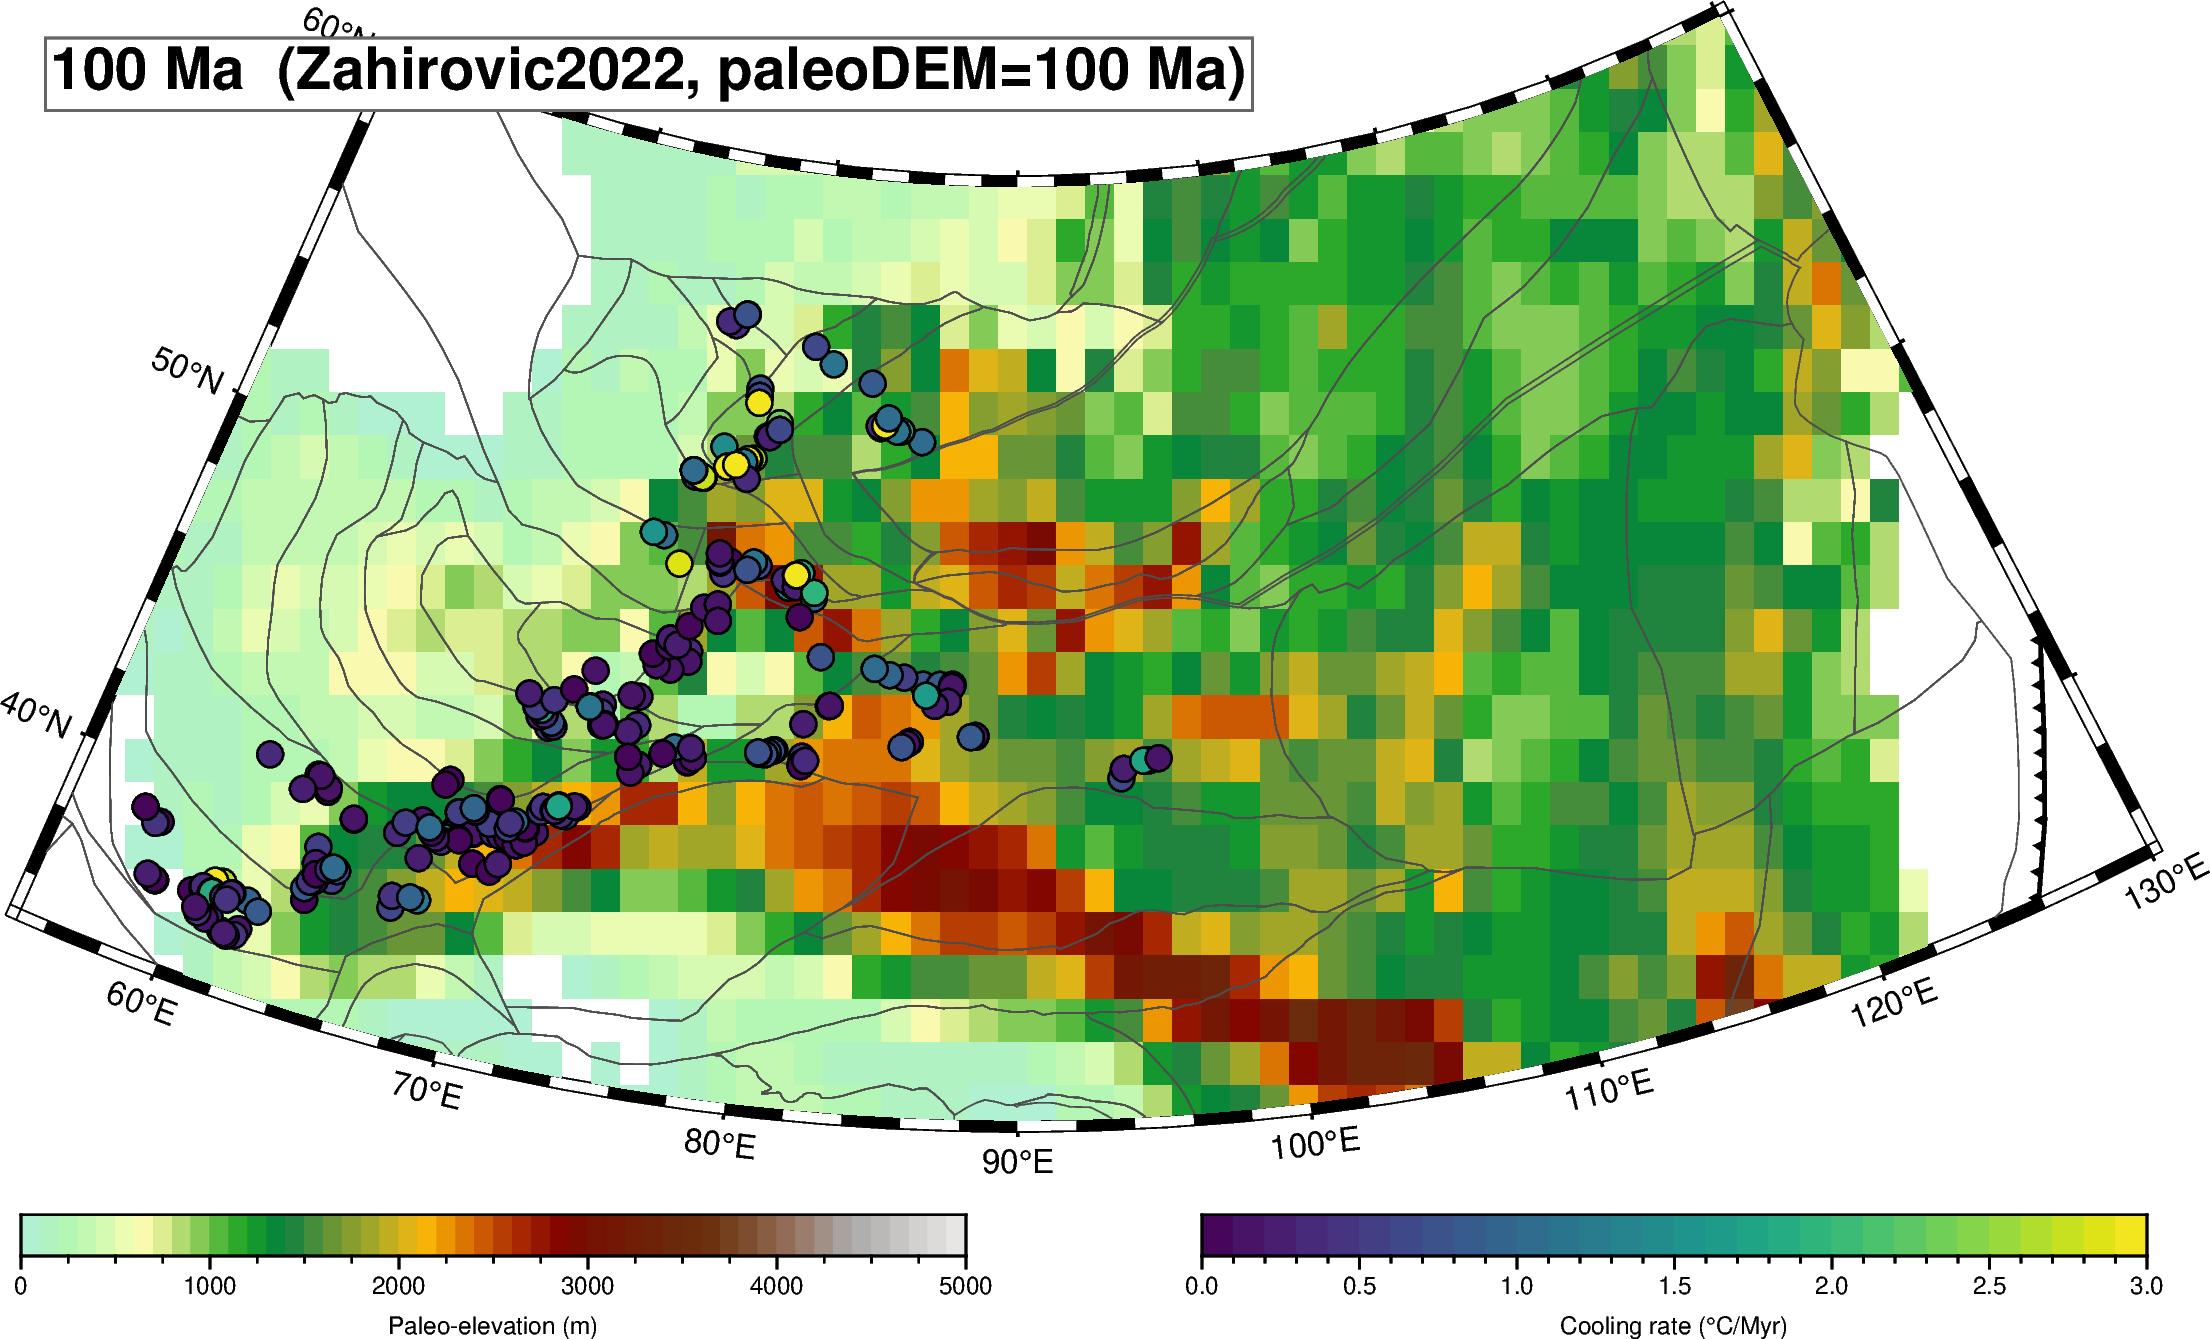

In [11]:
fig_C = pygmt.Figure()
fig_C.basemap(region=REGION_CENTRAL_ASIA, projection="B90/45/30/60/18c",
              frame=["af", "WSne"])
# Land-only paleotopography: clip to >= 0 m so the bathymetric colours
# don't bleed in.
pt_land = pt_da.where(pt_da >= 0)
pygmt.makecpt(cmap="dem4", series=[0, 5000, 100], background="o")
fig_C.grdimage(pt_land, cmap=True, nan_transparent=True)
gplot.time = float(RECONSTRUCTION_TIME)
gplot.plot_continents(fig_C, fill=None, pen="0.3p,gray30")
    gplot.plot_all_topological_sections(fig_C, pen="0.5p,black")  # thin BLACK backbone — full network visible underneath the styled ridges/trenches/teeth
engine.plot_geo_data_frame(fig_C, gplot.get_all_topological_sections(), pen="0.5p,black")
gplot.plot_ridges(fig_C, pen="1p,red3")
gplot.plot_trenches(fig_C, pen="1p,black")
gplot.plot_subduction_teeth(fig_C, color="black")
fig_C.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/0.8c",
               frame=["xa1000f250+lPaleo-elevation (m)"])
pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
fig_C.plot(x=samples_now["rlon"], y=samples_now["rlat"],
           fill=samples_now["cooling_rate"], cmap=True,
           style="c0.22c", pen="0.5p,black")
fig_C.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/0.8c",
               frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])
fig_C.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME}, paleoDEM={pt_age} Ma)",
           position="TL", offset="0.25c/-0.25c", justify="TL",
           font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig_C.show(width=800)

### What this figure shows you

The geochemistry-corrected Scotese & Wright (2018) paleo-DEM (dem4 palette) reveals the relief field the Central Asian samples were sitting on at 100 Ma — well before the modern Himalayan and Tian Shan ranges reached their present height. Even at 100 Ma, however, substantial inherited relief is visible across the Tian Shan / proto-Tibet region (light brown / orange in the corrected paleo-DEM); the fastest-cooling samples sit on or near these already-elevated areas. This is the spatial coincidence Boone et al. (2025) build on: cooling pulses track regions of *pre-existing* high relief because that's where the major crustal-scale shear zones are — favourably oriented to be reactivated by Tethyan-margin compression. The zhou-correction here matters because the uncorrected Scotese-Wright paleo-DEM under-represents cratonic-keel elevations and would visually understate that pre-existing relief.

## 8. Four-snapshot grid — cooling rates × ΔDT/Δt through time

Loops the DT-overlay map over five representative ages spanning the available
Young 2022 DT cadence: 200, 120, 100, 20, 0 Ma. Each panel is rendered as an
individual `pygmt.Figure` (house style — no `pygmt.subplot`).

The figures above are a single-age snapshot; Boone et al. (2025) ran the
same comparison through the entire 230–0 Ma window (their script 03 produces
one PNG per age). This loop reproduces the time-evolution version for the
ΔDT/Δt overlay at four centennial ages spanning Boone's window: 300 Ma
(late Variscan), 200 Ma (active Tethyan margin), 100 Ma (mid-Cretaceous
Tethyan subduction transition), and 0 Ma (modern). These four ages were
chosen because each has both a Young 2022 grid step at `age` *and* at
`age + 20 Ma` — both are needed to compute the ΔDT/Δt rate. The spatial
migration of fast-cooling samples relative to the mantle-flow-driven
uplift-and-subsidence pattern through this sequence is what motivates the
next notebook (T49) — looking at the kinematic and fault context that
surrounds each cooling phase.

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


  150 Ma — 226 samples; ΔDT pair 145-150 Ma


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


  100 Ma — 286 samples; ΔDT pair 94-104 Ma


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


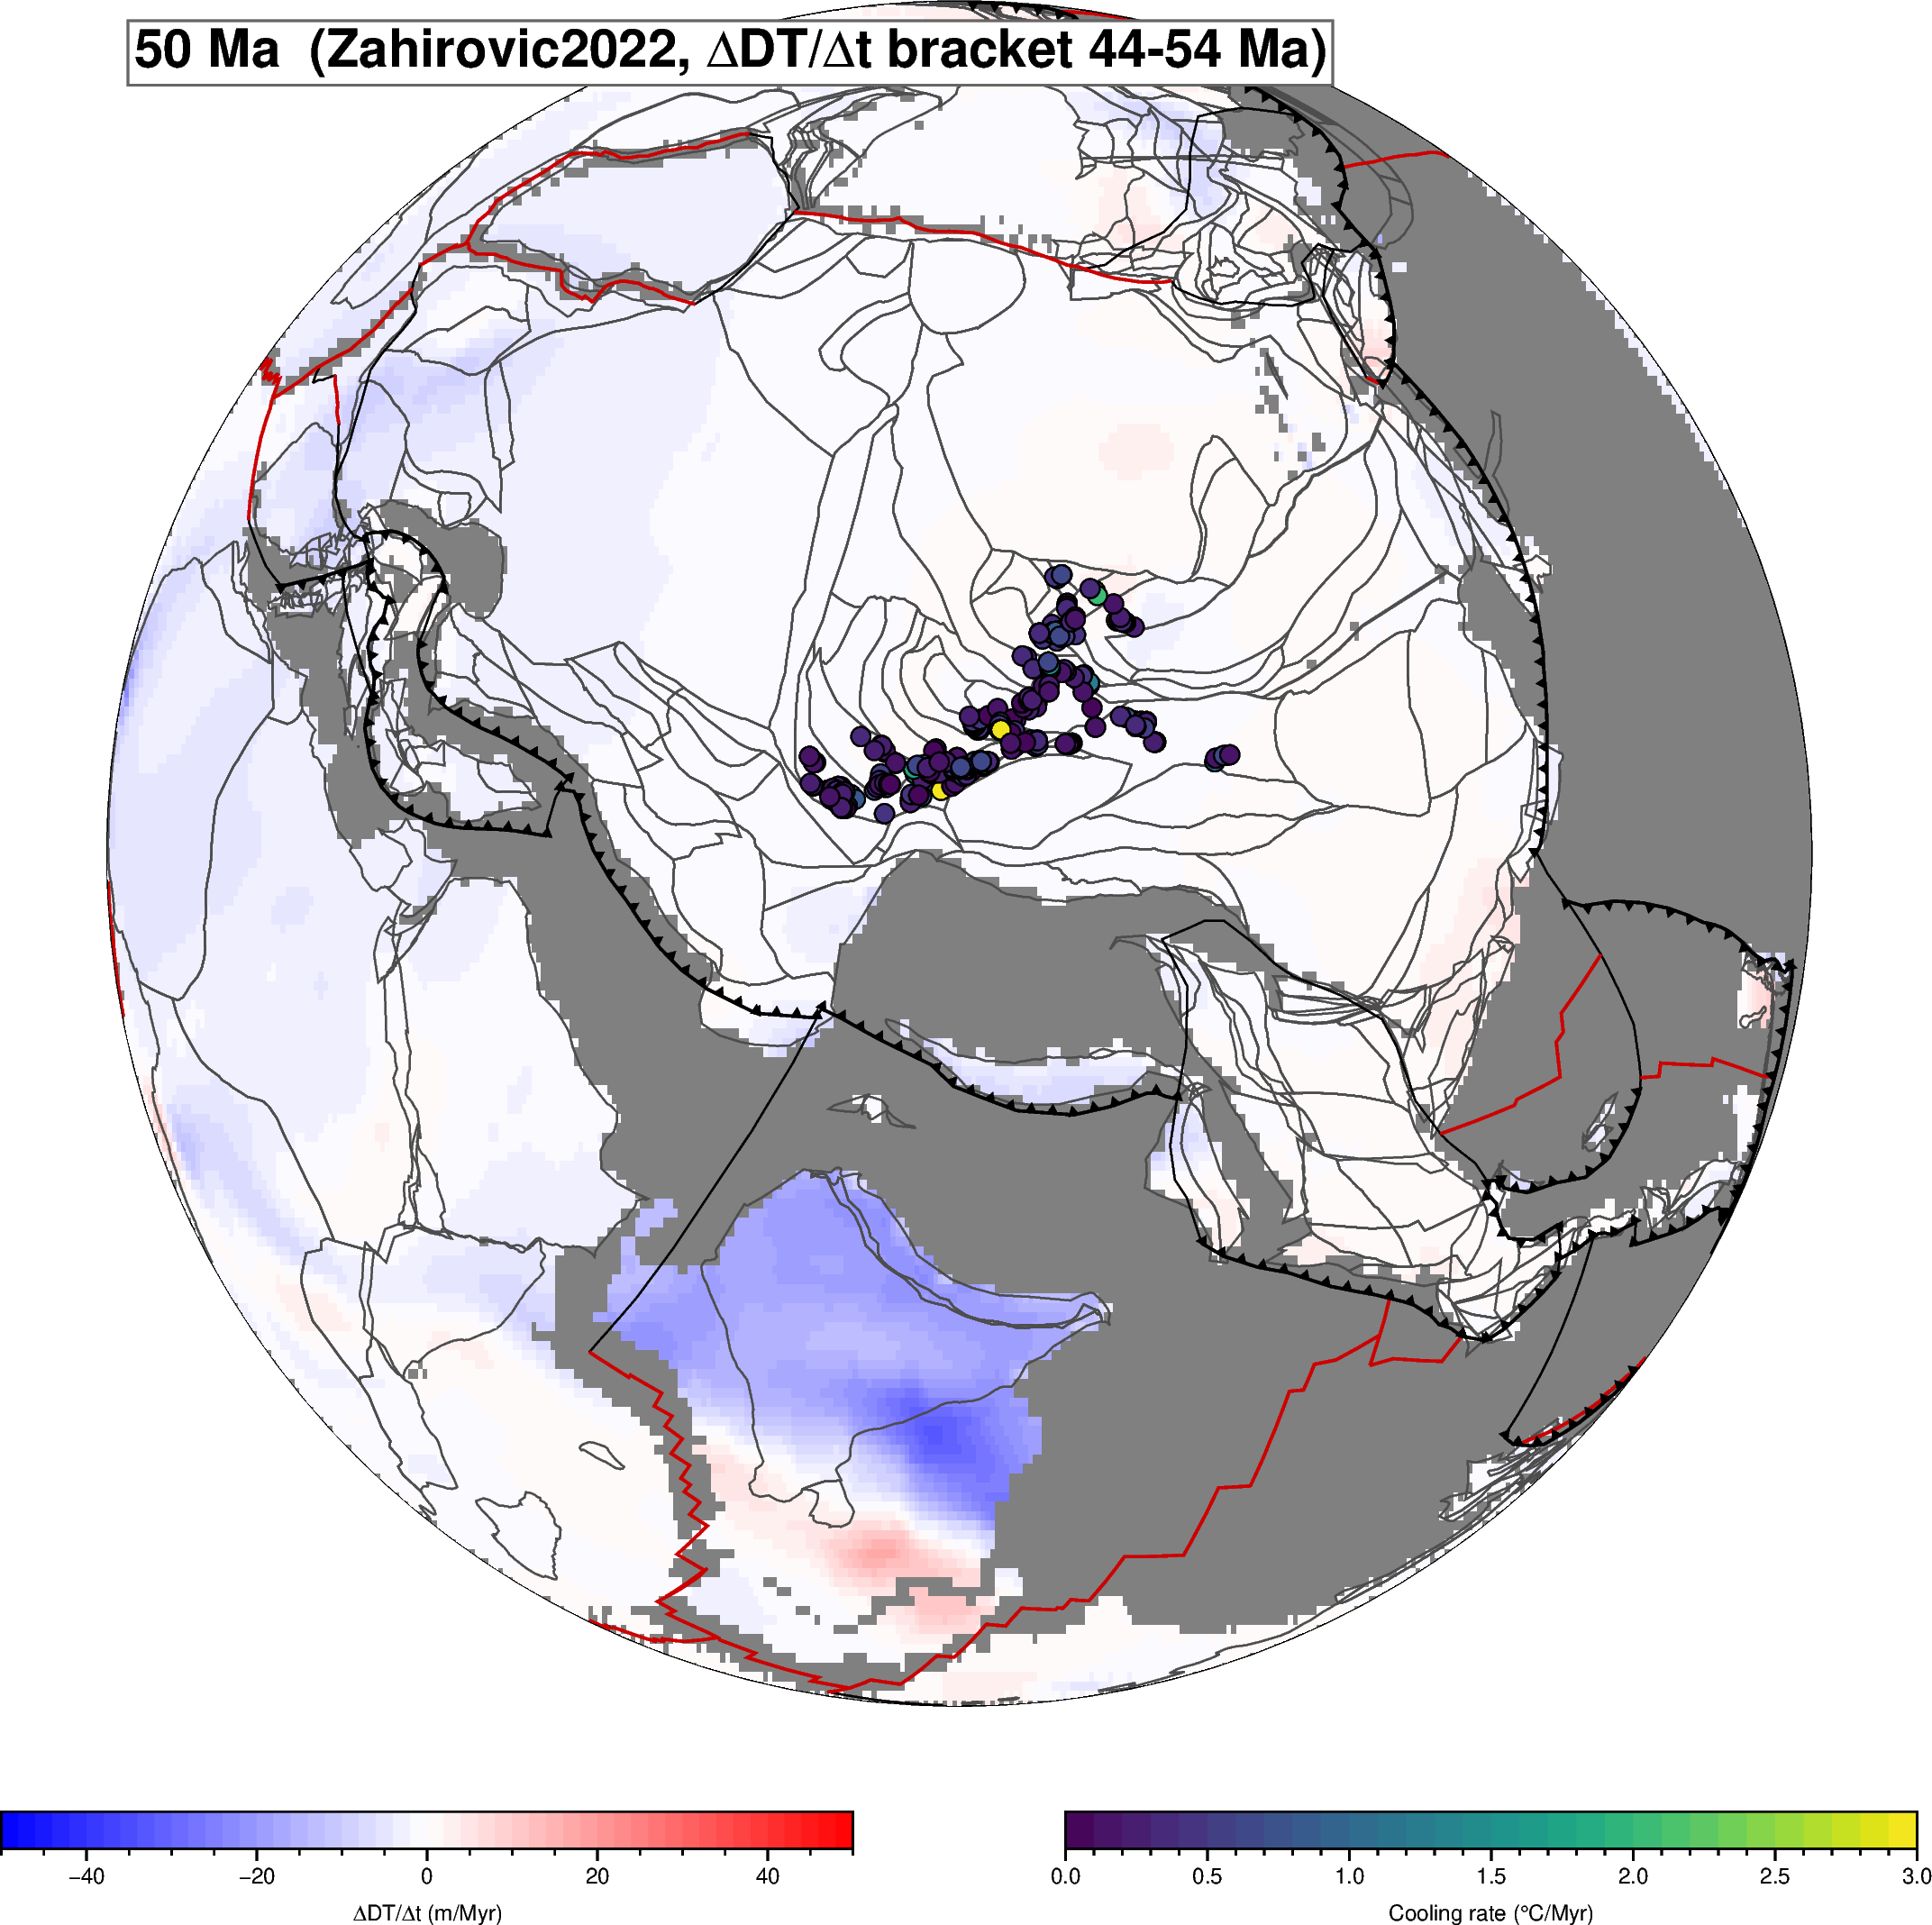

   50 Ma — 297 samples; ΔDT pair 44-54 Ma


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


    0 Ma — 38 samples; ΔDT pair 0-4 Ma


In [12]:
# Four-snapshot ΔDT/Δt loop in the gmcm9 coverage window (0-150 Ma).
# Each panel: compute Δ in plate frame, rotate to mantle frame, drop
# cooling-rate dots on top. Mirrors §6 (Layer B) but per snapshot age.
SNAPSHOTS_MA = [150, 100, 50, 0]

for t in SNAPSHOTS_MA:
    samp_t = per_sample_cooling_at(t, hist)
    if samp_t.empty:
        print(f"  {t:>3} Ma: no samples bracket this age, skipping")
        continue
    gpts_t = gplately.Points(recon,
                              samp_t["lon"].to_numpy(float),
                              samp_t["lat"].to_numpy(float),
                              anchor_plate_id=ANCHOR_PLATE_ID)
    rl_t, ra_t = gpts_t.reconstruct(float(t),
                                     return_array=True,
                                     anchor_plate_id=ANCHOR_PLATE_ID)
    samp_t = samp_t.assign(rlon=rl_t, rlat=ra_t).dropna(subset=["rlon", "rlat"])

    # gmcm9 plate-frame ΔDT/Δt via bracketing 5-Myr pair, then rotate
    nearest_t = _nearest_dt_age(t)
    idx_t     = _avail_dt_ages.index(nearest_t)
    lb_t      = _avail_dt_ages[max(0, idx_t - 1)]
    eb_t      = _avail_dt_ages[min(len(_avail_dt_ages) - 1, idx_t + 1)]
    if eb_t == lb_t:
        print(f"  {t:>3} Ma: cannot bracket nearest gmcm9 grid — skipping")
        continue
    dz_pf_t = (xr.open_dataset(DT_GRID_DIR / DT_GRID_PATTERN.format(age=lb_t))["z"]
               - xr.open_dataset(DT_GRID_DIR / DT_GRID_PATTERN.format(age=eb_t))["z"]
              ) / (eb_t - lb_t)
    dz_pf_t.name = "z"
    dt_rate_t = rotate_plate_frame_to_paleomag(dz_pf_t, float(t))

    gplot.time = float(t)
    fig = pygmt.Figure()
    fig.basemap(region="d", projection=GLOBAL_PROJ, frame=["af"])
    pygmt.makecpt(cmap="polar", series=[-50, 50, 2], background="o")
    fig.grdimage(dt_rate_t, cmap=True)
    gplot.plot_continents(fig, fill=None, pen="0.5p,gray30")
    gplot.plot_all_topological_sections(fig, pen="0.5p,black")  # thin BLACK backbone — full network visible underneath the styled ridges/trenches/teeth
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(), pen="0.5p,black")
    gplot.plot_ridges(fig, pen="0.8p,red3")
    gplot.plot_trenches(fig, pen="0.8p,black")
    gplot.plot_subduction_teeth(fig, color="black")
    fig.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/1c",
                 frame=["xa20f5+l@~D@~DT/@~D@~t (m/Myr)"])
    pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
    fig.plot(x=samp_t["rlon"], y=samp_t["rlat"],
             fill=samp_t["cooling_rate"], cmap=True,
             style="c0.18c", pen="0.4p,black")
    fig.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/1c",
                 frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])
    fig.text(text=f"{t:.0f} Ma  ({MODEL_NAME}, @~D@~DT/@~D@~t bracket {lb_t:.0f}-{eb_t:.0f} Ma)",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
    fig.show(width=800)
    print(f"  {t:>3} Ma — {len(samp_t)} samples; ΔDT pair {lb_t:.0f}-{eb_t:.0f} Ma")


### What this figure shows you

The polar palette shows ΔDT/Δt — the rate at which Earth's surface is being deflected by mantle flow at 100 Ma, in metres per million years. Red = currently uplifting from below; blue = currently subsiding. Compare the *colour of each cooling-rate dot's background*: if mantle-flow uplift were driving exhumation, the fastest-cooling (yellow) dots would cluster on red anomalies. They generally do not. Most fast-cooling Central Asian samples at 100 Ma sit on near-zero or weakly negative ΔDT/Δt — exactly the visual signature behind Boone et al. (2025)'s conclusion that dynamic-topography uplift played a *relatively insignificant role* in Central Asian Mesozoic exhumation. T50 quantifies this absence-of-correlation rigorously via Pearson r across the entire 0–150 Ma window.

## Extend this

- **Add a paleoprecipitation layer.** Boone et al. (2025) use Valdes-Scotese paleoprecipitation NetCDFs (`raster_data_Valdes-Scotese-precip-m-per-year_${age}.00Ma.nc`). Download a per-age set and add a `precip_da` raster + `samples_now["paleoprecip"]` column to the master parquet — T50 will pick it up automatically.
- **Sweep through the Phanerozoic.** Wrap the snapshot loop above to write per-age `thermochron_master_*.parquet` files across 0–230 Ma; this populates the substrate that **T50** (cross-variable correlations + time-series) consumes for Pearson-r-vs-age and means-vs-age analyses.
- **Switch the dynamic-topography model.** Re-run with a different DT reconstruction (Cao 2024, mantle-frame Müller 2022) to test how the cooling-rate vs DT relationship depends on mantle-convection model choice.
- **Plate-kinematics overlays.** Convergence-rate and trench-migration overlays + rose diagrams + fault-proximity analysis live in **T49** (Cooling rates × plate kinematics × fault analysis), which uses the same per-sample table as input.
